In [1]:
"""
TASK 2: Impact of Forecast Accuracy
============================================================
What this notebook is for: this notebook takes the two BESS schedules you
produced in Task 1 -- one solved under PERFECT forecast data
(optimal_BESS_perfect.csv) and one solved under SYNTHETIC forecast data
(optimal_BESS_synthetic.csv) -- and evaluates what happens financially when
the synthetic-forecast schedule is actually executed against real (perfect)
conditions.

What you need to do in this notebook: nothing needs to be coded -- just
upload the required files and run every cell.

Before you run this notebook, upload these four files to the Colab file
panel (folder icon on the left-hand side):
  - perfect_load.csv
  - perfect_pv.csv
  - optimal_BESS_synthetic.csv  (produced by Task 1 notebook, synthetic run)
  - optimal_BESS_perfect.csv    (produced by Task 1 notebook, perfect run)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# SECTION: Data loading helpers
# (No changes needed -- identical to the Task 1 notebook, reused here so this
#  notebook can stand on its own.)
# ==============================================================================
def read_load_generation(load_file, pv_file):
    """
    Read load and generation from CSV files
    """
    df_load = pd.read_csv(load_file)
    df_pv = pd.read_csv(pv_file)

    dates = df_load.iloc[:, 0].astype(str).tolist()

    load_profiles = df_load.iloc[:, 1:].values.flatten()
    pv_profiles = df_pv.iloc[:, 1:].values.flatten()
    days = len(df_load)

    # Use 4-day load and generation data rather than 5-day data
    days = max(days - 1, 1)
    steps_per_day_local = df_load.shape[1] - 1  # number of readings per day: 48 steps
    dates = dates[:days]
    load_profiles = load_profiles[:days * steps_per_day_local]
    pv_profiles = pv_profiles[:days * steps_per_day_local]

    return load_profiles, pv_profiles, days, dates

def generate_eta_profiles(days, steps_per_day):
    """
    Generates the daily time-of-use tariff and copies it
    across the entire multi-day horizon.
    """
    eta_day = np.zeros(steps_per_day)
    eta_day[np.r_[0:14, 44:48]] = 0.03   # Off-peak rate ($/kWh)
    eta_day[np.r_[14:28, 40:44]] = 0.06  # Shoulder rate ($/kWh)
    eta_day[28:40]               = 0.30  # Peak rate ($/kWh)

    eta_profiles = np.tile(eta_day, days)
    return eta_profiles


TASK 2 Forecast Error Evaluation & Financial Loss Analysis
Number of Days Analyzed:                       4 days (192 steps)
Schedule Mean Absolute Error (MAE):            742.85 kW
Ideal Electricity Bill (Executing Perfect Forecast Schedule):     $3732.46
Actual Electricity Bill (Executing Synthetic Schedule):  $5281.20
Financial Loss Incurred due to Forecast Error: $1548.75


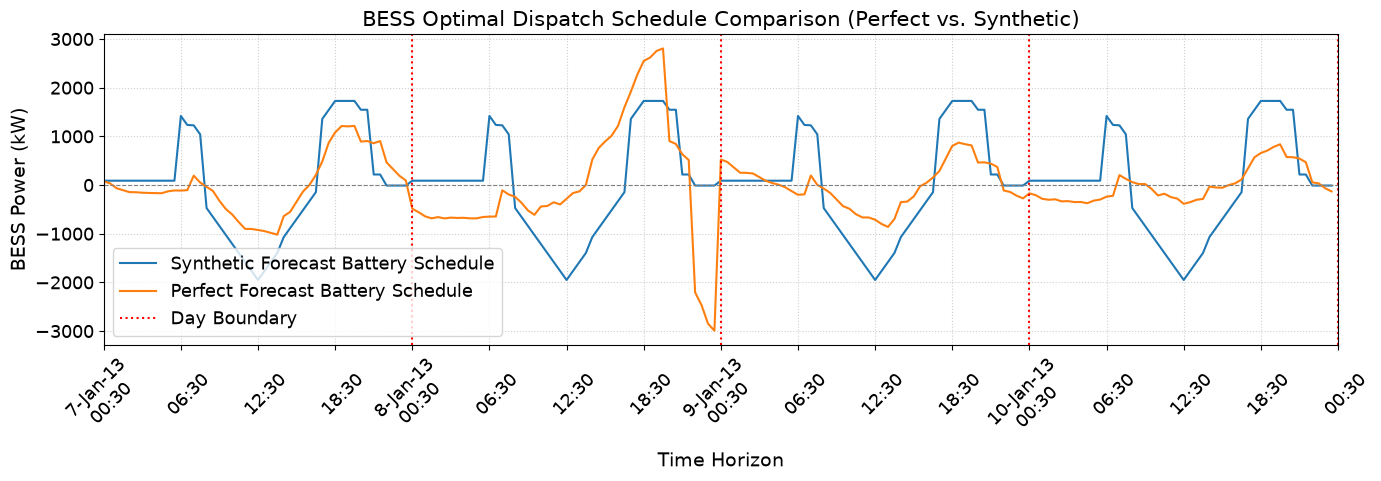

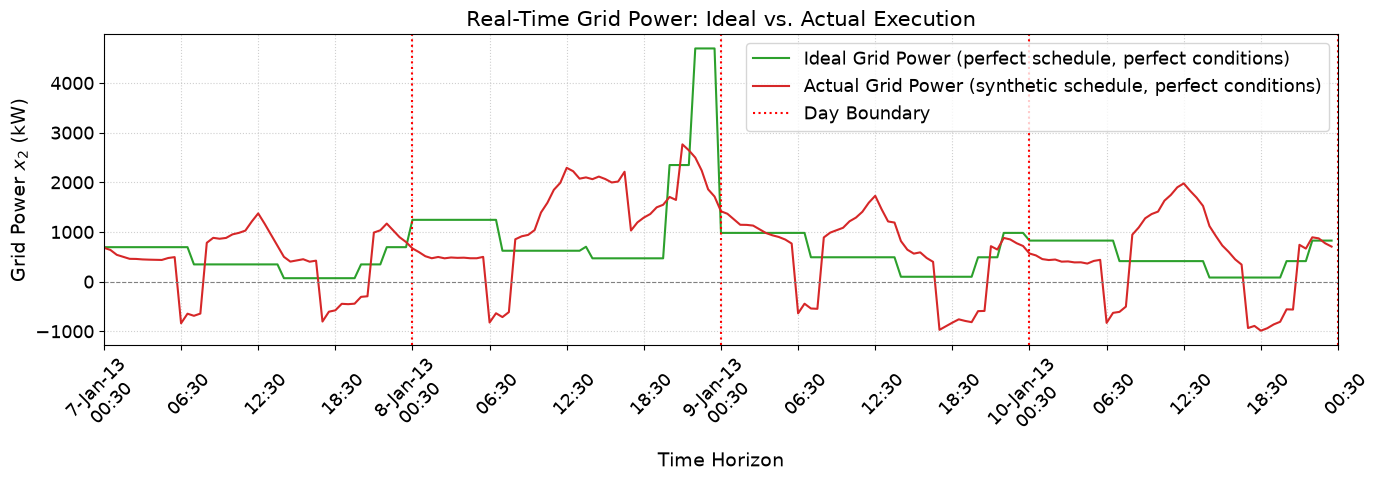

In [2]:
"""
MAIN ANALYSIS
============================================================
No changes needed -- just run this cell. It will:
  1. Load the perfect load/PV data and the tariff.
  2. Load the two pre-computed BESS schedules (synthetic vs. perfect forecast).
  3. Compute the schedule MAE, the resulting real-world grid power under each
     schedule, and the electricity bills / financial loss.
  4. Plot the two BESS dispatch schedules overlaid, and the two resulting
     grid power trajectories overlaid.
"""

### ---- Step 1: Load the perfect load/PV data and tariff ----
### (These represent what actually happens -- used as ground truth to
###  evaluate the synthetic schedule against.)
load_csv_path = 'perfect_load.csv'
pv_csv_path = 'perfect_pv.csv'
steps_per_day = 48
delta = 0.5

perfect_load, perfect_pv, days, dates = read_load_generation(load_csv_path, pv_csv_path)
total_horizon = days * steps_per_day

# Generate tariff profile
eta_profiles = generate_eta_profiles(days, steps_per_day)

### Build the same day-boundary timeline (in hours, with date tick labels)
### used in the Task 1 notebook, so the x-axis here matches Task 1's plots.
time_indices_total = np.arange(total_horizon)
timeline_hours = time_indices_total * delta

### ---- Step 2: Load the two pre-computed optimal BESS schedules from Task 1 ----
df_syn = pd.read_csv('optimal_BESS_synthetic.csv')      # solved using synthetic forecast
df_perfect = pd.read_csv('optimal_BESS_perfect.csv')     # solved using perfect forecast

x1_syn = df_syn['BESS_Power_x1_kW'].values
x1_perfect = df_perfect['BESS_Power_x1_kW'].values
time_steps = df_syn['Time_Step'].values

### ---- Step 3: Quantify how much the two schedules disagree ----
### Mean Absolute Error between the two BESS power schedules.
mae = np.mean(np.abs(x1_perfect - x1_syn))

### ---- Step 4: Simulate what actually happens to the grid ----
### Ideal case: the perfect-forecast schedule is executed under the
### (matching) perfect conditions -- this is the best-case benchmark.
x2_ideal = perfect_load - perfect_pv - x1_perfect

### Real-world case: the synthetic-forecast schedule is executed, but the
### ACTUAL conditions are the perfect load/PV data -- i.e. the schedule the
### battery operator commits to doesn't match what really happens, so the
### grid must absorb the difference.
x2_actual = perfect_load - perfect_pv - x1_syn

### ---- Step 5: Electricity bill calculations ($) ----
bill_ideal = np.sum(eta_profiles * x2_ideal * delta)
bill_actual = np.sum(eta_profiles * x2_actual * delta)
financial_loss = bill_actual - bill_ideal

### ---- Step 6: Print results summary (Task 2 on the grade sheet) ----
print("=" * 60)
print("TASK 2 Forecast Error Evaluation & Financial Loss Analysis")
print("=" * 60)
print(f"Number of Days Analyzed:                       {days} days ({len(time_steps)} steps)")
print(f"Schedule Mean Absolute Error (MAE):            {mae:.2f} kW")
print(f"Ideal Electricity Bill (Executing Perfect Forecast Schedule):     ${bill_ideal:.2f}")
print(f"Actual Electricity Bill (Executing Synthetic Schedule):  ${bill_actual:.2f}")
print(f"Financial Loss Incurred due to Forecast Error: ${financial_loss:.2f}")
print("=" * 60)


# ==============================================================================
# Plot configuration
# ==============================================================================
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'savefig.dpi': 300
})

### ---- Build day-boundary x-axis ticks (same style as Task 1's plot_results) ----
total_hours = timeline_hours[-1] + delta
tick_hours = np.arange(0, total_hours + 1, 6)
time_labels = []
for h in tick_hours:
    day_idx = int(h // 24)
    time_str = f"{int(h % 24):02d}:30"
    if h % 24 == 0 and day_idx < days:
        time_labels.append(f"{dates[day_idx]}\n{time_str}")
    else:
        time_labels.append(f"\n{time_str}")

### ---- Figure 1: BESS schedule comparison (synthetic vs. perfect) ----
plt.figure(figsize=(14, 5))
plt.plot(timeline_hours, x1_syn, label='Synthetic Forecast Battery Schedule', linewidth=1.5)
plt.plot(timeline_hours, x1_perfect, label='Perfect Forecast Battery Schedule', linewidth=1.5)

for d in range(1, days):
    plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.5)
plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=1.5, label='Day Boundary')

plt.title('BESS Optimal Dispatch Schedule Comparison (Perfect vs. Synthetic)')
plt.xlabel('Time Horizon')
plt.ylabel('BESS Power (kW)')
plt.xlim(0, total_hours)
plt.xticks(tick_hours, time_labels, rotation=45)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('task2_bess_comparison.png', dpi=300)
plt.show()


### ---- Figure 2 (NEW): Grid power comparison -- x2_ideal vs. x2_actual ----
### This is the plot that lets you directly see where the real-world grid
### power diverges from the ideal benchmark, and connect that to the
### financial loss above (Task 2 on the grade sheet). Uses the same
### day-boundary timeline as Task 1's plots.
plt.figure(figsize=(14, 5))
plt.plot(timeline_hours, x2_ideal, label='Ideal Grid Power (perfect schedule, perfect conditions)', linewidth=1.5, color='tab:green')
plt.plot(timeline_hours, x2_actual, label='Actual Grid Power (synthetic schedule, perfect conditions)', linewidth=1.5, color='tab:red')

for d in range(1, days):
    plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.5)
plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=1.5, label='Day Boundary')

plt.title('Real-Time Grid Power: Ideal vs. Actual Execution')
plt.xlabel('Time Horizon')
plt.ylabel('Grid Power $x_2$ (kW)')
plt.xlim(0, total_hours)
plt.xticks(tick_hours, time_labels, rotation=45)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('task2_grid_power_comparison.png', dpi=300)
plt.show()
